I want to test multiple day prediction for the first time

In [121]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [122]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor, pinball_loss_sum, normalize_batch, compute_mean_std

In [123]:
class simple_net(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 80)
        self.fc2 = nn.Linear(80, 80)
        self.fc3 = nn.Linear(80, 80)
        self.fc4 = nn.Linear(80, output_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


In [124]:
all_specs = [
    "sales",
    "7_day_rolling_ema",	
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "30_day_rolling_min",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "dif_180_day",
]

In [125]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[("store", 1), ("item", 1)],
    specs=all_specs,
    days_to_predict=2
    )

In [126]:
h_cost = 1
l_cost = 3
num_epochs = 500

In [127]:
# Full feature width → all targets (not thread_net-style input // num_outputs)
input_dim = train_loader.dataset.x.shape[1]
output_dim = train_loader.dataset.y.shape[1]

In [128]:
print(f"Predict Shape: {train_loader.dataset.y.shape}")

Predict Shape: torch.Size([1461, 2])


First compute with Normalization

In [129]:
from torch._tensor import Tensor


net_1 = simple_net(input_dim=input_dim, output_dim=output_dim)

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial[Tensor](pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_1.parameters(), lr=0.001)

train_losses, val_losses = train(net_1, optimizer, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True)

test_loss = get_test_loss(net_1, test_loader, og_loss, "cpu")

Training: 100%|██████████| 500/500 [00:06<00:00, 81.86step/s, train_loss=4.9305]                    


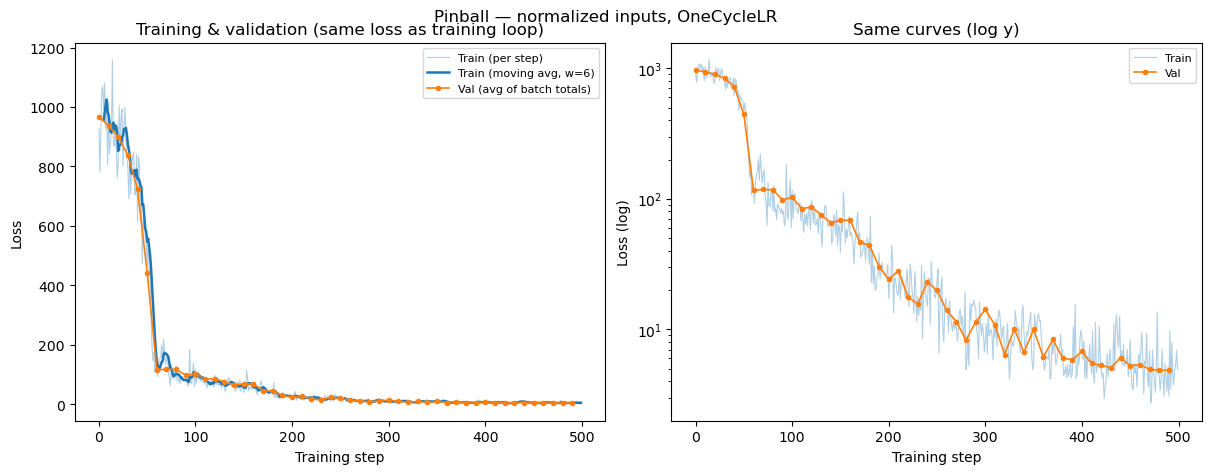

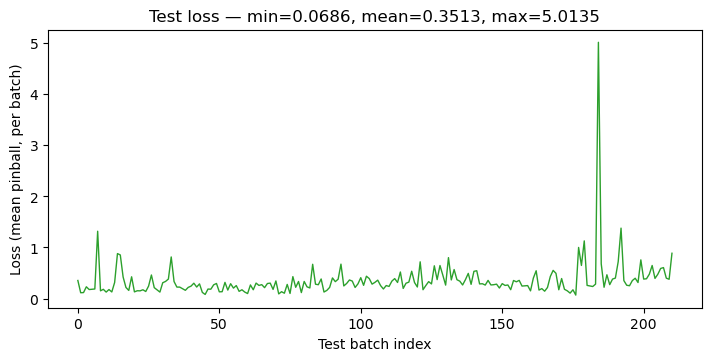

In [130]:
# Plot losses (set eval_interval to match train(..., eval_interval=...))
eval_interval = 10

train_steps = np.arange(len(train_losses))
val_steps = np.arange(len(val_losses), dtype=float) * eval_interval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: linear scale — train/val both use the same `loss` passed to train() (here: batch sum)
ax = axes[0]
ax.plot(train_steps, train_losses, color="C0", alpha=0.35, linewidth=0.8, label="Train (per step)")
if len(train_losses) >= 20:
    k = max(1, len(train_losses) // 80)
    kernel = np.ones(k) / k
    smooth = np.convolve(train_losses, kernel, mode="valid")
    ax.plot(np.arange(k - 1, len(train_losses)), smooth, color="C0", linewidth=1.8, label=f"Train (moving avg, w={k})")
if len(val_losses):
    ax.plot(
        val_steps,
        val_losses,
        color="C1",
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Val (avg of batch totals)",
    )
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title("Training & validation (same loss as training loop)")
ax.legend(loc="upper right", fontsize=8)

# Right: log y
ax = axes[1]
ax.semilogy(train_steps, np.maximum(train_losses, 1e-12), color="C0", alpha=0.35, linewidth=0.8, label="Train")
if len(val_losses):
    ax.semilogy(val_steps, np.maximum(val_losses, 1e-12), color="C1", marker="o", markersize=3, linewidth=1.2, label="Val")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss (log)")
ax.set_title("Same curves (log y)")
ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Pinball — normalized inputs, OneCycleLR", fontsize=12, y=1.02)
plt.show()

# Test uses `og_loss` (mean per batch) — scale differs from train/val sum; shown separately
if len(test_loss):
    t = np.asarray(test_loss, dtype=float)
    min_t, mean_t, max_t = float(t.min()), float(t.mean()), float(t.max())
    fig2, ax2 = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
    ax2.plot(np.arange(len(t)), t, color="C2", linewidth=1.0)
    ax2.set_xlabel("Test batch index")
    ax2.set_ylabel("Loss (mean pinball, per batch)")
    ax2.set_title(f"Test loss — min={min_t:.4f}, mean={mean_t:.4f}, max={max_t:.4f}")
    plt.show()

In [131]:
# Get the data
train_loader_2, val_loader_2, test_loader_2 = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[("store", 1), ("item", 1)],
    specs=all_specs,
    days_to_predict=1
    )
input_dim = train_loader_2.dataset.x.shape[1]
output_dim = train_loader_2.dataset.y.shape[1]

net = simple_net(input_dim=input_dim, output_dim=output_dim)

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial[Tensor](pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses_2, val_losses_2 = train(net, optimizer, loss, train_loader_2, val_loader_2, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True)

test_loss_2 = get_test_loss(net, test_loader_2, og_loss, "cpu")

Training: 100%|██████████| 500/500 [00:06<00:00, 82.61step/s, train_loss=63.5339]                    


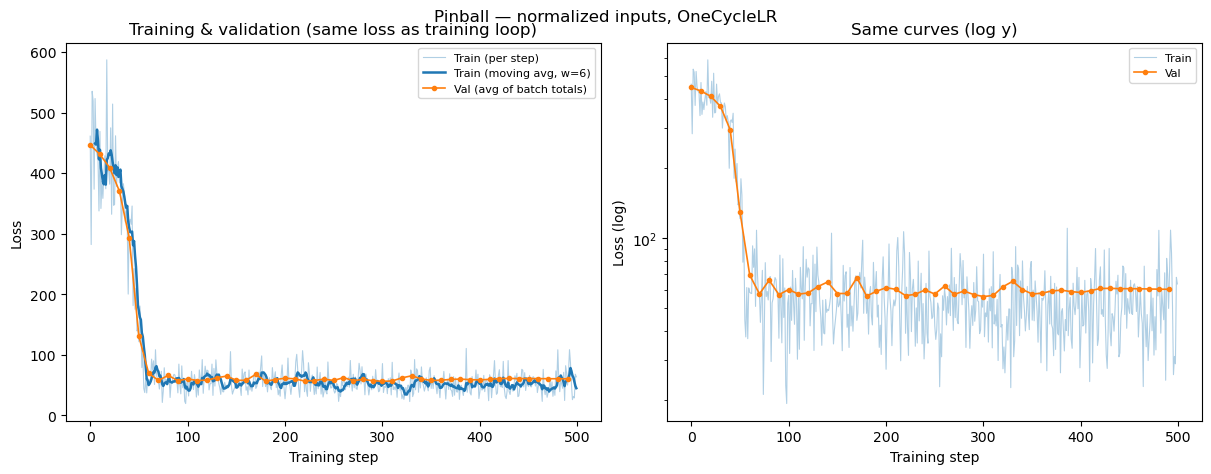

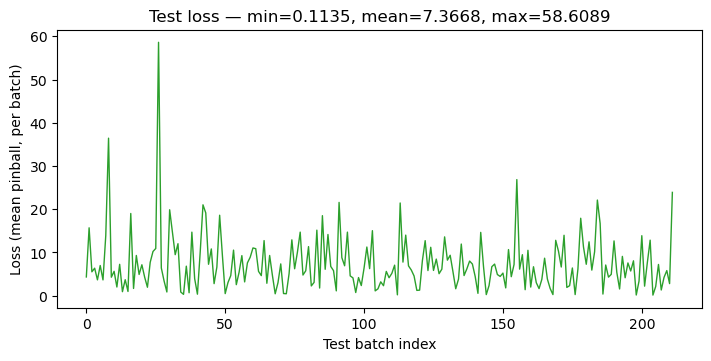

In [132]:
# Plot losses (set eval_interval to match train(..., eval_interval=...))
eval_interval = 10

train_steps = np.arange(len(train_losses_2))
val_steps = np.arange(len(val_losses_2), dtype=float) * eval_interval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: linear scale — train/val both use the same `loss` passed to train() (here: batch sum)
ax = axes[0]
ax.plot(train_steps, train_losses_2, color="C0", alpha=0.35, linewidth=0.8, label="Train (per step)")
if len(train_losses_2) >= 20:
    k = max(1, len(train_losses_2) // 80)
    kernel = np.ones(k) / k
    smooth = np.convolve(train_losses_2, kernel, mode="valid")
    ax.plot(np.arange(k - 1, len(train_losses_2)), smooth, color="C0", linewidth=1.8, label=f"Train (moving avg, w={k})")
if len(val_losses_2):
    ax.plot(
        val_steps,
        val_losses_2,
        color="C1",
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Val (avg of batch totals)",
    )
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title("Training & validation (same loss as training loop)")
ax.legend(loc="upper right", fontsize=8)

# Right: log y
ax = axes[1]
ax.semilogy(train_steps, np.maximum(train_losses_2, 1e-12), color="C0", alpha=0.35, linewidth=0.8, label="Train")
if len(val_losses_2):
    ax.semilogy(val_steps, np.maximum(val_losses_2, 1e-12), color="C1", marker="o", markersize=3, linewidth=1.2, label="Val")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss (log)")
ax.set_title("Same curves (log y)")
ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Pinball — normalized inputs, OneCycleLR", fontsize=12, y=1.02)
plt.show()

# Test uses `og_loss` (mean per batch) — scale differs from train/val sum; shown separately
if len(test_loss_2):
    t = np.asarray(test_loss_2, dtype=float)
    min_t, mean_t, max_t = float(t.min()), float(t.mean()), float(t.max())
    fig2, ax2 = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
    ax2.plot(np.arange(len(t)), t, color="C2", linewidth=1.0)
    ax2.set_xlabel("Test batch index")
    ax2.set_ylabel("Loss (mean pinball, per batch)")
    ax2.set_title(f"Test loss — min={min_t:.4f}, mean={mean_t:.4f}, max={max_t:.4f}")
    plt.show()

In [133]:
# Per test row: pinball loss for one horizon (batch size must be 1).
# horizon_idx 0 → 1-day-ahead (same target as single-day `next_sales` / multi `day_1`).
# horizon_idx 1 → 2-day-ahead (`day_2`) when days_to_predict >= 2.
def get_test_loss_mod(
    net: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    loss: callable,
    device: str,
    horizon_idx: int = 0,
) -> list[float]:
    test_losses = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_hat = net(x)
            test_loss = loss(y_hat[0, horizon_idx], y[0, horizon_idx])
            test_losses.append(test_loss.item())
    return test_losses

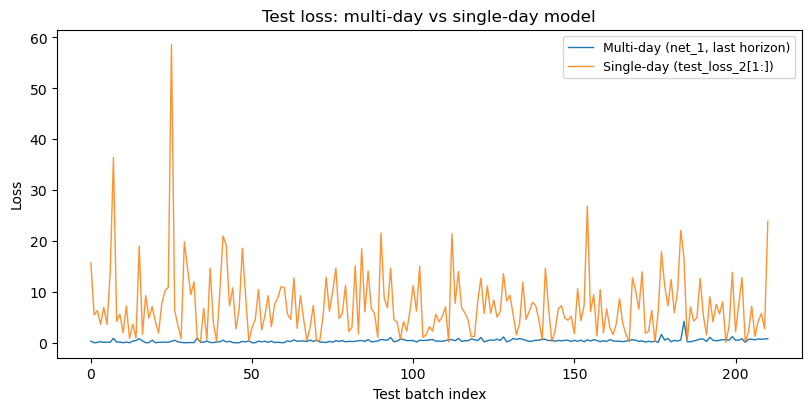

Multi-day:  mean=0.410932  min=0.001221  max=4.229031
Single-day: mean=7.381306  min=0.113470  max=58.608864


In [135]:
multi_day_test_loss = get_test_loss_mod(net_1, test_loader, og_loss, "cpu", horizon_idx=1)
single_day_test_loss = test_loss_2[1:]

md = np.asarray(multi_day_test_loss, dtype=float)
sd = np.asarray(single_day_test_loss, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(np.arange(len(md)), md, color="C0", linewidth=1.0, label="Multi-day (net_1, last horizon)")
ax.plot(np.arange(len(sd)), sd, color="C1", linewidth=1.0, alpha=0.85, label="Single-day (test_loss_2[1:])")
ax.set_xlabel("Test batch index")
ax.set_ylabel("Loss")
ax.set_title("Test loss: multi-day vs single-day model")
ax.legend(loc="best", fontsize=9)
plt.show()

print(
    f"Multi-day:  mean={md.mean():.6f}  min={md.min():.6f}  max={md.max():.6f}"
)
print(
    f"Single-day: mean={sd.mean():.6f}  min={sd.min():.6f}  max={sd.max():.6f}"
)